In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("house_price_dataset_india_12k.csv")

In [ ]:
df.head()

,House_ID,City,Locality_Tier,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,...,Furnishing,Lift,Gated_Society,Distance_to_Metro_km,Distance_to_CityCenter_km,Nearby_School_km,Nearby_Hospital_km,Crime_Rate_Index,Market_Price_INR,Price_per_sqft_INR
0,1,Hyderabad,Mid,3,4,957.3,809.1,11,15,8,...,Semi-Furnished,1,0,2.44,20.76,1.77,3.52,32.4,7736451,8082
1,2,Bangalore,Budget,2,3,883.3,711.7,13,16,13,...,Semi-Furnished,1,0,0.48,17.56,2.82,4.86,66.3,5771877,6534
2,3,Pune,Premium,3,4,1331.5,1087.1,13,15,7,...,Unfurnished,1,1,2.76,9.73,0.20,1.75,23.3,14688106,11031
3,4,Mumbai,Premium,3,4,997.6,801.0,7,19,10,...,Semi-Furnished,1,1,1.12,13.15,0.27,0.61,18.8,19094254,19140
4,5,Pune,Mid,2,2,967.6,707.6,5,16,6,...,Unfurnished,1,1,2.46,14.07,3.34,3.93,41.0,7592420,7847


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   House_ID                   12000 non-null  int64  
 1   City                       12000 non-null  object 
 2   Locality_Tier              12000 non-null  object 
 3   BHK                        12000 non-null  int64  
 4   Bathrooms                  12000 non-null  int64  
 5   Super_Area_sqft            12000 non-null  float64
 6   Carpet_Area_sqft           12000 non-null  float64
 7   Floor_No                   12000 non-null  int64  
 8   Total_Floors               12000 non-null  int64  
 9   Property_Age_years         12000 non-null  int64  
 10  Parking                    12000 non-null  int64  
 11  Furnishing                 12000 non-null  object 
 12  Lift                       12000 non-null  int64  
 13  Gated_Society              12000 non-null  int

In [ ]:
df.describe()

,House_ID,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,Parking,Lift,Gated_Society,Distance_to_Metro_km,Distance_to_CityCenter_km,Nearby_School_km,Nearby_Hospital_km,Crime_Rate_Index,Market_Price_INR,Price_per_sqft_INR
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,1.200000e+04,12000.000000
mean,6000.50000,2.304167,2.536083,1018.260342,763.563383,7.599000,15.232667,8.615917,0.640083,0.924167,0.588667,2.153820,14.101654,2.807817,3.059477,41.756825,1.020406e+07,9689.409667
std,3464.24595,0.934909,1.102482,379.974189,291.095491,5.685352,5.707604,5.374815,0.479996,0.264742,0.492096,1.817501,7.149948,1.352786,1.507851,13.716940,6.707595e+06,4279.861543
min,1.00000,1.000000,1.000000,350.000000,250.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.500000,0.200000,0.300000,5.000000,1.356119e+06,2480.000000
25%,3000.75000,2.000000,2.000000,781.800000,569.700000,3.000000,11.000000,4.000000,0.000000,1.000000,0.000000,0.410000,9.000000,1.840000,1.990000,32.200000,5.586925e+06,6562.750000
50%,6000.50000,2.000000,2.000000,950.500000,715.550000,7.000000,15.000000,8.000000,1.000000,1.000000,1.000000,1.830000,14.010000,2.800000,3.000000,41.800000,8.558740e+06,8763.000000
75%,9000.25000,3.000000,3.000000,1226.300000,915.200000,11.000000,19.000000,12.000000,1.000000,1.000000,1.000000,3.340000,19.000000,3.760000,4.080000,51.400000,1.304248e+07,11980.000000
max,12000.00000,5.000000,7.000000,3010.400000,2285.900000,32.000000,38.000000,33.000000,1.000000,1.000000,1.000000,11.600000,39.800000,8.710000,8.810000,85.400000,5.755283e+07,22626.000000


In [ ]:
df.isnull().sum()

,0
House_ID,0
City,0
Locality_Tier,0
BHK,0
Bathrooms,0
Super_Area_sqft,0
Carpet_Area_sqft,0
Floor_No,0
Total_Floors,0
Property_Age_years,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print(
("city:",df["City"].unique()),
("Locality:",df["Locality_Tier"].unique()),
("Furnishing:",df["Furnishing"].unique())
)

('city:', array(['Hyderabad', 'Bangalore', 'Pune', 'Mumbai', 'Nagpur'], dtype=object)) ('Locality:', array(['Mid', 'Budget', 'Premium'], dtype=object)) ('Furnishing:', array(['Semi-Furnished', 'Unfurnished', 'Fully-Furnished'], dtype=object))


In [ ]:
##convert categorical to numerial

df = pd.get_dummies(df, columns=["City","Locality_Tier","Furnishing"],drop_first=True)

In [ ]:
df.head()

,House_ID,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,Parking,Lift,...,Market_Price_INR,Price_per_sqft_INR,City_Hyderabad,City_Mumbai,City_Nagpur,City_Pune,Locality_Tier_Mid,Locality_Tier_Premium,Furnishing_Semi-Furnished,Furnishing_Unfurnished
0,1,3,4,957.3,809.1,11,15,8,1,1,...,7736451,8082,True,False,False,False,True,False,True,False
1,2,2,3,883.3,711.7,13,16,13,1,1,...,5771877,6534,False,False,False,False,False,False,True,False
2,3,3,4,1331.5,1087.1,13,15,7,1,1,...,14688106,11031,False,False,False,True,False,True,False,True
3,4,3,4,997.6,801.0,7,19,10,1,1,...,19094254,19140,False,True,False,False,False,True,True,False
4,5,2,2,967.6,707.6,5,16,6,1,1,...,7592420,7847,False,False,False,True,True,False,False,True


In [ ]:
df.isnull().sum()

,0
House_ID,0
BHK,0
Bathrooms,0
Super_Area_sqft,0
Carpet_Area_sqft,0
Floor_No,0
Total_Floors,0
Property_Age_years,0
Parking,0
Lift,0


In [ ]:
x = df.drop(["House_ID", "Market_Price_INR", "Price_per_sqft_INR"], axis=1)
y = df["Market_Price_INR"]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
Lr_model = LinearRegression()
RFR_model = RandomForestRegressor()
GBR_model = GradientBoostingRegressor()





In [ ]:
#training
Lr_model.fit(x_train,y_train)
RFR_model.fit(x_train,y_train)
GBR_model.fit(x_train,y_train)



GradientBoostingRegressor()

In [ ]:
#prediction
Lr_pred = Lr_model.predict(x_test)
RFR_pred = RFR_model.predict(x_test)
GBR_pred = GBR_model.predict(x_test)

In [ ]:
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, Lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, Lr_pred)))
print("R2:", r2_score(y_test, Lr_pred))

Linear Regression
MAE: 1327363.2283291006
RMSE: 1939826.6317508407
R2: 0.9151930871424666


In [ ]:
print(" RandomForestRegressor")
print("MAE:", mean_absolute_error(y_test, RFR_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, RFR_pred)))
print("R2:", r2_score(y_test, RFR_pred))

 RandomForestRegressor
MAE: 590935.9361375
RMSE: 806653.2482506762
R2: 0.9853350970452215


In [ ]:
print("GradientBoostingRegressor")
print("MAE:", mean_absolute_error(y_test, GBR_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, GBR_pred)))
print("R2:", r2_score(y_test, GBR_pred))

GradientBoostingRegressor
MAE: 612759.0228622692
RMSE: 857233.9002536683
R2: 0.9834383312467977


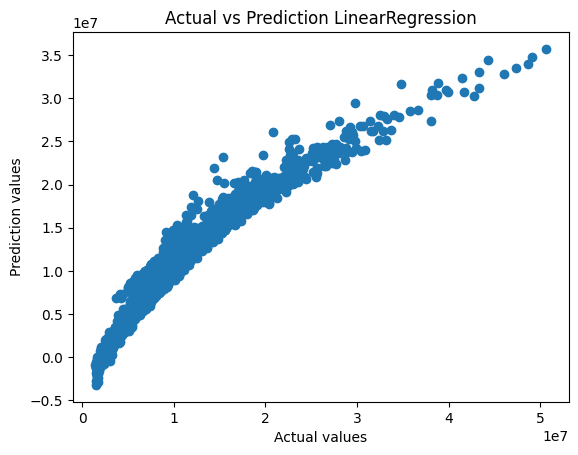

In [ ]:
plt.scatter(y_test,Lr_pred)
plt.xlabel("Actual values")
plt.ylabel("Prediction values")
plt.title("Actual vs Prediction LinearRegression")
plt.show()

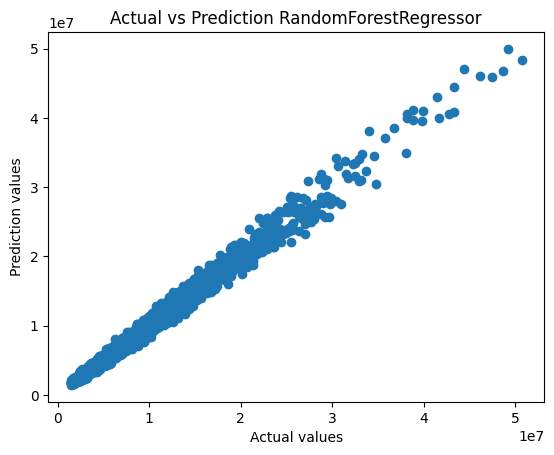

In [ ]:
plt.scatter(y_test,RFR_pred)
plt.xlabel("Actual values")
plt.ylabel("Prediction values")
plt.title("Actual vs Prediction RandomForestRegressor")
plt.show()

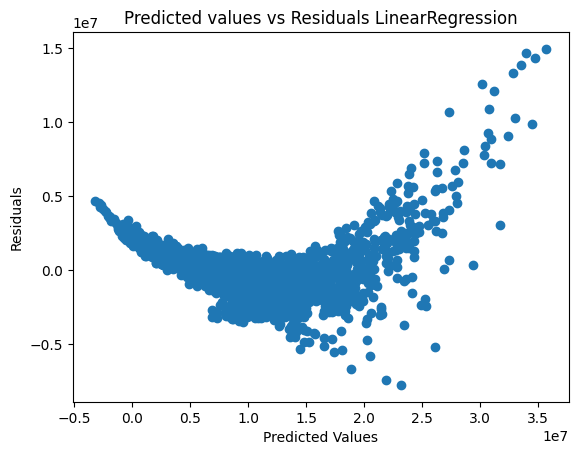

In [ ]:
residuals = y_test-Lr_pred
plt.scatter(Lr_pred,residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Predicted values vs Residuals LinearRegression")
plt.show()

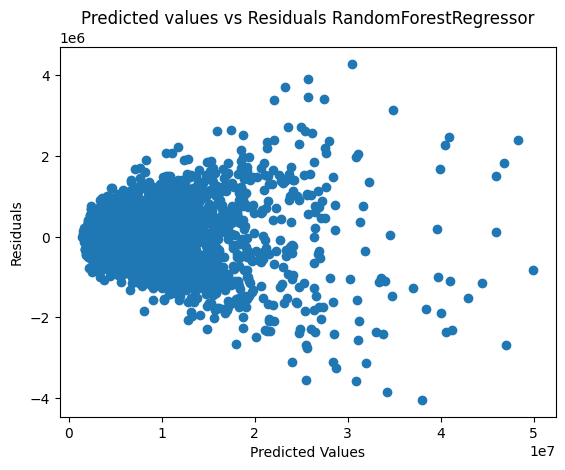

In [ ]:
residuals = y_test-RFR_pred
plt.scatter(RFR_pred,residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Predicted values vs Residuals RandomForestRegressor")
plt.show()